# Визуализация на ДНК Dot-Plot матрица
Проект: Паралелно сравнение на ДНК последователности (OpenMP)

В тази секция визуализираме изходните данни от нашия паралелен алгоритъм. Използваме файла output.csv, генериран при тестване със Small Dataset.

Сини точки: Представят всички случайни съвпадения между базите (A, T, C, G).

Червени точки: Маркират основния диагонал на подреждане (alignment), където двете секвенции съвпадат най-точно.

# КОД


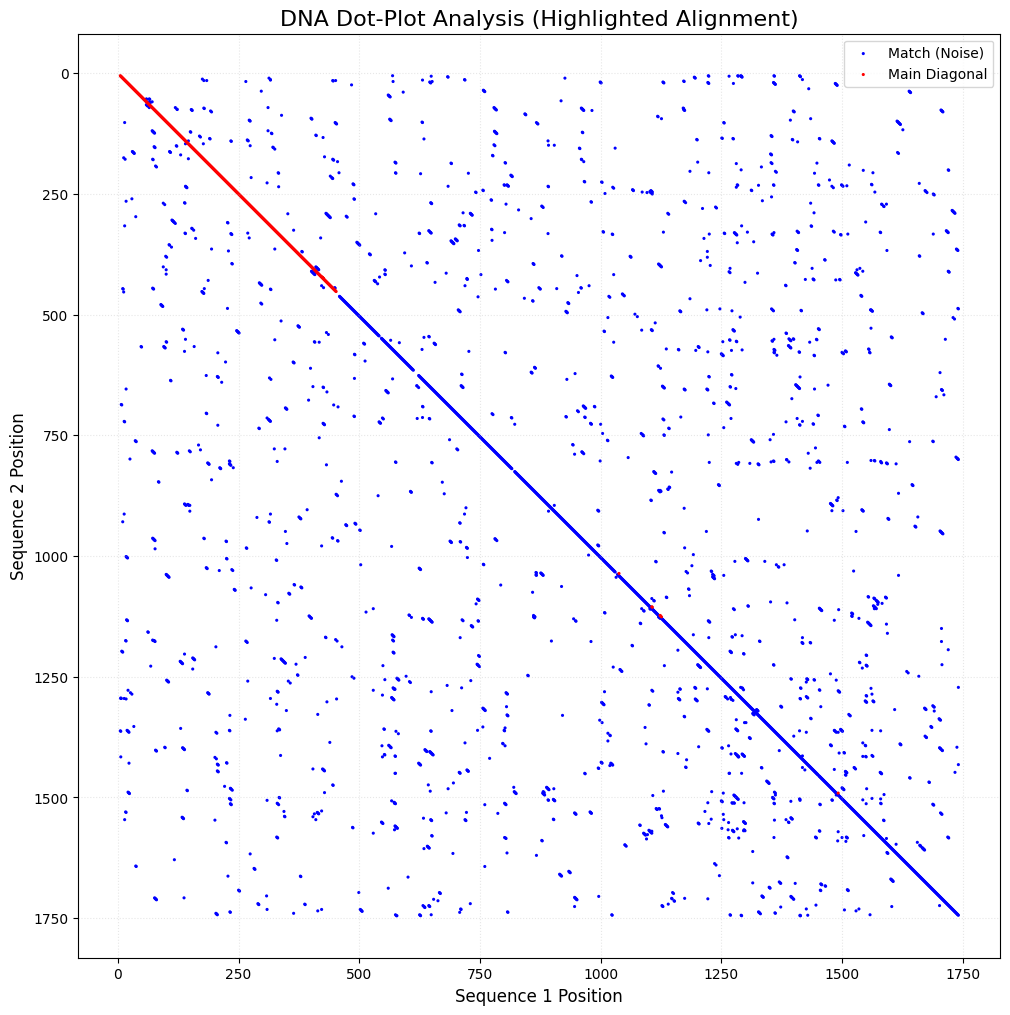

Общо точки: 4301
Точки в диагонала: 459


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

try:
    df = pd.read_csv('output.csv', header=0)

    df['X'] = pd.to_numeric(df.iloc[:, 0], errors='coerce')
    df['Y'] = pd.to_numeric(df.iloc[:, 1], errors='coerce')
    df = df.dropna()

    tolerance = 2
    is_diagonal = np.abs(df['X'] - df['Y']) <= tolerance

    df_diag = df[is_diagonal]
    df_noise = df[~is_diagonal]

    plt.figure(figsize=(12, 12))

    plt.scatter(df_noise['X'], df_noise['Y'], s=5, c='blue', alpha=1, edgecolors='none', label='Match (Noise)')

    plt.scatter(df_diag['X'], df_diag['Y'], s=5, c='red', alpha=1, edgecolors='none', label='Main Diagonal')

    plt.title('DNA Dot-Plot Analysis (Highlighted Alignment)', fontsize=16)
    plt.xlabel('Sequence 1 Position', fontsize=12)
    plt.ylabel('Sequence 2 Position', fontsize=12)
    plt.gca().invert_yaxis()
    plt.grid(True, linestyle=':', alpha=0.3)
    plt.legend(loc='upper right')

    plt.gca().set_aspect('equal', adjustable='box')
    plt.savefig("dna_alignment_highlighted.png", dpi=300)
    plt.show()

    print(f"Общо точки: {len(df)}")
    print(f"Точки в диагонала: {len(df_diag)}")

except Exception as e:
    print(f"Възникна грешка: {e}")